In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]  # importing functions from other folders

sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import abbrev_stat
from _fitting.model_utils_smooth import *
# from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import re
import pytensor.tensor as pt
from pytensor.gradient import disconnected_grad
from scipy.sparse.linalg import eigsh
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba

az.style.use("arviz-darkgrid")

if '___laptop' in os.listdir('../../'):

    # laptop folder
    folder = "../../../_data/p-dengue/"
elif '___server' in os.listdir('../../'):

    # server folder
    folder = "../../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[smooth_s1|6_selection]"]

In [3]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 3, 5]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

In [4]:
def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        # s_match = re.search(r'std=(True|False)', name)
        stat_match = re.search(r'\[([a-zA-Z0-9_()]+)\]', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            # 'std': s_match.group(1) == 'True' if s_match else None,
            'stat_name': stat_match.group(1) if stat_match else None,
        }

In [5]:
p_vals_ = [1.0]
num_knots_list_ = [5]
statistics_ = ['rh_mean_pop_weighted(0)']

p_set = set(p_vals_) if p_vals_ is not None else None
k_set = set(num_knots_list_) if num_knots_list_ is not None else None
# std_set = set(std) if std is not None else None
stat_set = set(statistics_) if statistics_ is not None else None

In [7]:
model_settings_dict = {}
model_dict = {} 
idata_dict = {}

for stat_name in statistics_:
        for num_knots in num_knots_list_:
            for p in p_vals_:
                stat_names = [stat_name]
                abbrev_stat_names = [abbrev_stat(s) for s in stat_names]
                p_set = set([p])
                k_set = set([num_knots])
                abbrev_stat_set = set(abbrev_stat_names)
                
                settings = {
                    'alpha_type': 'exponential', 'alpha_parameters': {'lam': 0.5},
                    'intercept_type': 'normal', 'intercept_parameters': {'mu': -10.0, 'sigma': 1.0},
                    'beta_u_type': 'normal', 'beta_u_parameters': {'mu': 0, 'sigma': 1.0},
                    'link': None, 'link_stat_name': None, 'link_type': None,
                    'b1_type': None, 'b1_parameters': None,
                    'c_type': None, 'c_parameters': None,
                    'stat_names': stat_names, 'num_knots': num_knots, 'knot_type': 'equispaced', 'degree': 3,
                    'spline_implementation': 'svd', 'spline_type': 'halfnormal', 'spline_parameters': {'sigma_w_sigma': 10.0},
                    'penalty_order': 2, 'penalty_type': 'halfnormal', 'penalty_parameters': {'p': p}, 'penalty_std': False,
                    'cutoff': None,
                    'exclude': ['intercept', 'beta_u', 'alpha', 'zi_b1', 'zi_c'],
                    'surveillance_name': None,
                    'urbanisation_name': 'urbanisation_pop_weighted_std'}
                
                model_name = build_model_name(settings['alpha_type'], settings['alpha_parameters'],
                                settings['intercept_type'], settings['intercept_parameters'],
                                settings['link'], settings['link_stat_name'], settings['link_type'],
                                settings['b1_type'], settings['b1_parameters'],
                                settings['c_type'], settings['c_parameters'],
                                settings['stat_names'], settings['num_knots'], settings['knot_type'], settings['degree'],
                                settings['spline_implementation'], settings['spline_type'], settings['spline_parameters'],
                                settings['penalty_order'], settings['penalty_type'], settings['penalty_parameters'], settings['penalty_std'],
                                settings['cutoff'], settings['beta_u_type'], settings['beta_u_parameters'],
                                exclude=settings['exclude'],
                                surveillance_name=settings['surveillance_name'],
                                urbanisation_name=settings['urbanisation_name'])
                model_settings_dict[model_name] = settings

                model, m, B, knot_list = build_sig_spline_p_model(_data.copy(), **settings)
                model_dict[model_name] = model

                found = 0
                for run in run_folders:
                    idata_dir = os.path.join(model_fits_folder, run, 'idata')
                    # print(idata_dir)
                    if not os.path.isdir(idata_dir):
                        continue
                    for fname in os.listdir(idata_dir):
                        if not fname.endswith('.nc'):
                            continue
                        meta = parse_name(fname)
                        if p_set is not None and meta['p'] not in p_set:
                            continue
                        if k_set is not None and meta['num_knots'] not in k_set:
                            continue
                        # if std_set is not None and meta['std'] not in std_set:
                            # continue
                        if stat_set is not None and meta['stat_name'] not in abbrev_stat_set:
                            continue
                        # print(meta['p'], meta['num_knots'], meta['stat_name'])

                        idata_ = az.from_netcdf(os.path.join(idata_dir, fname))
                        idata_dict[model_name] = idata_
                        found = 1
                if found==0:
                    raise ValueError("No models matched the given filters.")

In [13]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

Warmup iterations saved (warmup_*).

In [ ]:
for m in model_dict:
    print(m)
    model = model_dict[m]
    idata = idata_dict.get(m)

    # Tile the posterior draws N times
    N = 10  # multiplier — gives you N × original draws
    idata_tiled = idata.copy()
    idata_tiled.posterior = idata.posterior.isel(
        draw=np.tile(np.arange(idata.posterior.dims["draw"]), N)
    )
    with model:
        posterior_predictive = pm.sample_posterior_predictive(idata_tiled).posterior_predictive

[rh_mean_p(0)]__pen(o2,p=1.0)__knots(5,equispaced,deg3,svd)


/tmp/ipykernel_1450742/1509620367.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  draw=np.tile(np.arange(idata.posterior.dims["draw"]), N)
/tmp/ipykernel_1450742/1509620367.py:13: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  posterior_predictive = pm.sample_posterior_predictive(idata_tiled, extend_inferencedata=True).posterior_predictive
Sampling: [y_obs]


Output()

In [73]:

obs = idata.observed_data['y_obs'].values
ppc = posterior_predictive['y_obs'].values
ppc = ppc.reshape(-1, 24107).T
ppc_mean = np.mean(ppc, axis=1)
ppc_median = np.median(ppc, axis=1)
ppc_hdi = {}
coverage = {}
for q in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    ppc_hdi[q] = az.hdi(ppc.T, hdi_prob=q)
    coverage[q] = np.mean((obs >= ppc_hdi[q][:, 0]) & (obs <= ppc_hdi[q][:, 1]))
    print(f'{q*100:.0f}% HDI Coverage: {coverage[q]}')

/tmp/ipykernel_1450742/2184757899.py:9: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  ppc_hdi[q] = az.hdi(ppc.T, hdi_prob=q)


10% HDI Coverage: 0.27274235699174515
20% HDI Coverage: 0.2926950678226241
30% HDI Coverage: 0.35811175177334387
40% HDI Coverage: 0.4487908076492305
50% HDI Coverage: 0.5543203218982038
60% HDI Coverage: 0.6633343012403037
70% HDI Coverage: 0.7635956361222881
80% HDI Coverage: 0.850997635541544
90% HDI Coverage: 0.9228025054963289
95% HDI Coverage: 0.9534989836976812


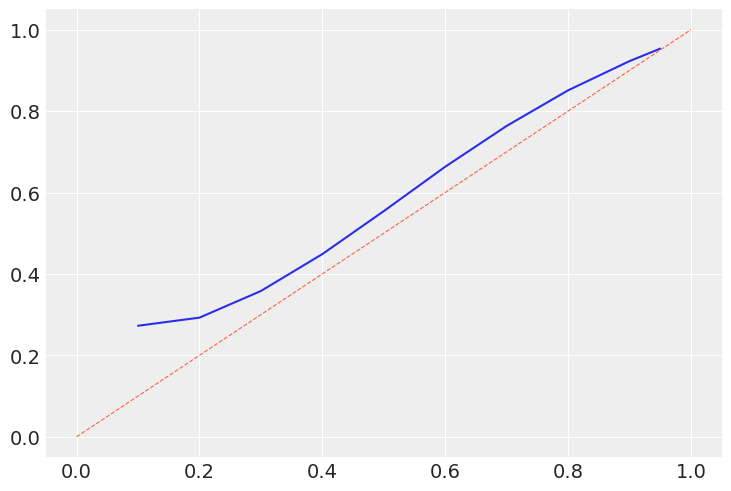

In [78]:
plt.plot(coverage.keys(), coverage.values())
plt.plot([0, 1], [0, 1], '--', lw=0.8, color='tomato')
plt.show()

In [70]:
data_ppc = _data.copy()
data_ppc['ppc'] = [ppc[i, :] for i in range(ppc.shape[0])]
data_ppc['ppc_mean'] = ppc_mean
data_ppc['ppc_median'] = ppc_median
data_ppc['ppc_hdi_1-q'] = ppc_hdi[:, 0]
data_ppc['ppc_hdi_q'] = ppc_hdi[:, 1]

data_ppc['ppc_mean_rate'] = data_ppc['ppc_mean']/data_ppc['population']
data_ppc['ppc_median_rate'] = data_ppc['ppc_median']/data_ppc['population']
data_ppc['ppc_hdi_1-q_rate'] = data_ppc['ppc_hdi_1-q']/data_ppc['population']
data_ppc['ppc_hdi_q_rate'] = data_ppc['ppc_hdi_q']/data_ppc['population']

0.49184782608695654


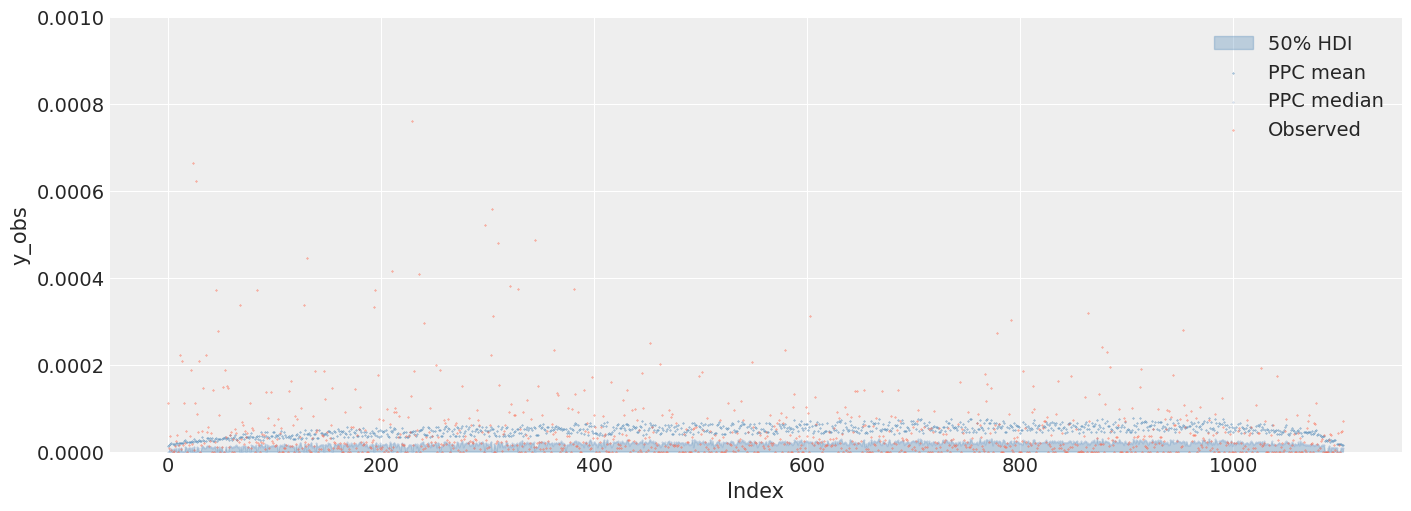

In [71]:
data_ppc = data_ppc.iloc[data_ppc['admin1']=='ACEH']
print(np.mean((data_ppc['rate'] >= data_ppc['ppc_hdi_1-q_rate']) & (data_ppc['rate'] <= data_ppc['ppc_hdi_q_rate'])))
data_ppc.sort_values(by='rh_mean_pop_weighted(0)', inplace=True)

idx = np.arange(len(data_ppc))

fig, ax = plt.subplots(figsize=(14, 5))

# HDI band
ax.fill_between(idx, data_ppc['ppc_hdi_1-q_rate'], data_ppc['ppc_hdi_q_rate'], alpha=0.3, color='steelblue', label=f'{q*100:.0f}% HDI')

# PPC mean and observed
ax.scatter(idx, data_ppc['ppc_mean_rate'], s=0.1, color='steelblue', label='PPC mean')
ax.scatter(idx, data_ppc['ppc_median_rate'], s=0.1, color='lightsteelblue', label='PPC median')
ax.scatter(idx, data_ppc['rate'], s=0.1, color='tomato', label='Observed')

ax.legend()
ax.set_xlabel('Index')
ax.set_ylabel('y_obs')
ax.set_ylim(0, 0.001)
plt.show()

KeyError: 'ppc_hdi_5%'

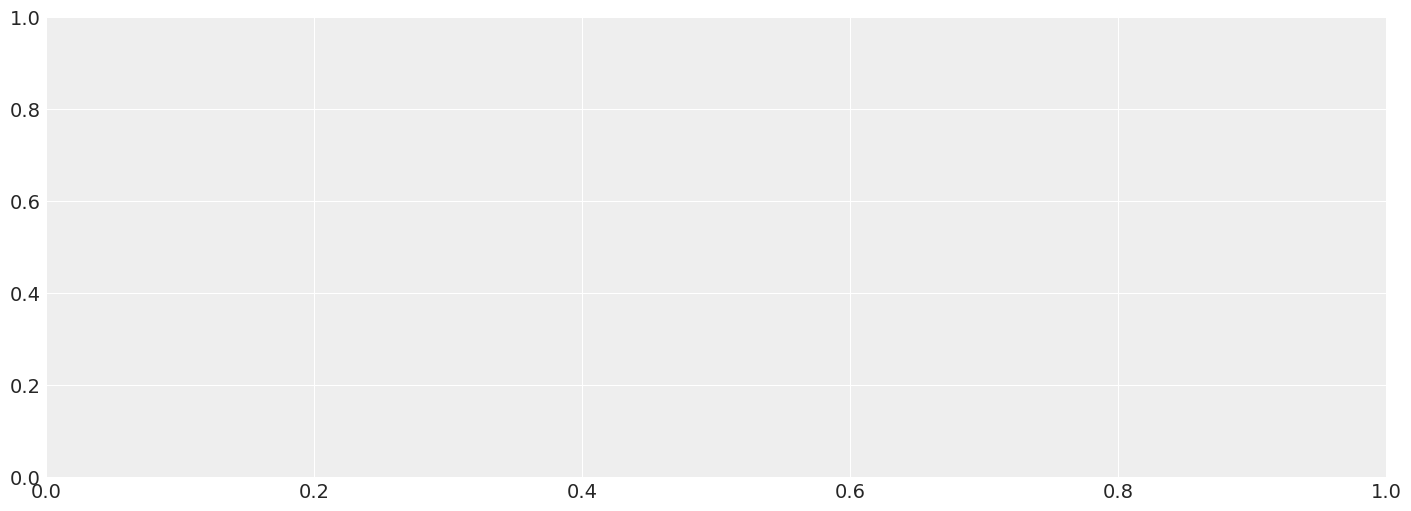

In [59]:
idx = np.arange(len(obs))

fig, ax = plt.subplots(figsize=(14, 5))

# HDI band
ax.fill_between(idx, data_ppc['ppc_hdi_5%'], data_ppc['ppc_hdi_95%'], alpha=0.3, color='steelblue', label='90% HDI')

# PPC mean and observed
ax.scatter(idx, data_ppc['ppc_mean'], s=2, color='steelblue', label='PPC mean')
ax.scatter(idx, obs, s=2, color='tomato', label='Observed')

ax.legend()
ax.set_xlabel('Index')
ax.set_ylabel('y_obs')
plt.show()

In [24]:
data_ppc = _data.copy()
data_ppc['ppc'] = [ppc[i, :] for i in range(ppc.shape[0])]

In [28]:
data_ppc['ppc_mean'] = data_ppc['ppc'].apply(lambda x: np.mean(x))
data_ppc['ppc_hdi_5%'] = data_ppc['ppc'].apply(lambda x: az.hdi(x, hdi_prob=0.95)[0])

In [29]:
data_ppc['ppc_hdi_5%']

0        0
1        0
2        0
3        0
4        0
        ..
24102    0
24103    0
24104    0
24105    0
24106    0
Name: ppc_hdi_5%, Length: 24107, dtype: int64

---

In [26]:
model_settings_dict = {}
model_dict = {} 
for stat_name in statistics_:
        for num_knots in num_knots_list_:
            for p in p_vals_:
                stat_names = [stat_name]
                settings = {
                    'alpha_type': 'exponential', 'alpha_parameters': {'lam': 0.5},
                    'intercept_type': 'normal', 'intercept_parameters': {'mu': -10.0, 'sigma': 1.0},
                    'beta_u_type': 'normal', 'beta_u_parameters': {'mu': 0, 'sigma': 1.0},
                    'link': None, 'link_stat_name': None, 'link_type': None,
                    'b1_type': None, 'b1_parameters': None,
                    'c_type': None, 'c_parameters': None,
                    'stat_names': stat_names, 'num_knots': num_knots, 'knot_type': 'equispaced', 'degree': 3,
                    'spline_implementation': 'svd', 'spline_type': 'halfnormal', 'spline_parameters': {'sigma_w_sigma': 10.0},
                    'penalty_order': 2, 'penalty_type': 'halfnormal', 'penalty_parameters': {'p': p}, 'penalty_std': False,
                    'cutoff': None,
                    'exclude': ['intercept', 'beta_u', 'alpha', 'zi_b1', 'zi_c'],
                    'surveillance_name': None,
                    'urbanisation_name': 'urbanisation_pop_weighted_std'}
                
                model_name = build_model_name(settings['alpha_type'], settings['alpha_parameters'],
                                settings['intercept_type'], settings['intercept_parameters'],
                                settings['link'], settings['link_stat_name'], settings['link_type'],
                                settings['b1_type'], settings['b1_parameters'],
                                settings['c_type'], settings['c_parameters'],
                                settings['stat_names'], settings['num_knots'], settings['knot_type'], settings['degree'],
                                settings['spline_implementation'], settings['spline_type'], settings['spline_parameters'],
                                settings['penalty_order'], settings['penalty_type'], settings['penalty_parameters'], settings['penalty_std'],
                                settings['cutoff'], settings['beta_u_type'], settings['beta_u_parameters'],
                                exclude=settings['exclude'],
                                surveillance_name=settings['surveillance_name'],
                                urbanisation_name=settings['urbanisation_name'])
                model_settings_dict[model_name] = settings

                model, m, B, knot_list = build_sig_spline_p_model(_data.copy(), **settings)
                model_dict[model_name] = model

In [42]:
idata_dict = {}
for stat_name in [abbrev_stat(s) for s in statistics_]:
        # print(stat_name, '\n')
        for num_knots in num_knots_list_:
            for p in p_vals_:
                stat_names = [stat_name]
                stat_set = set(stat_names) if stat_names is not None else None
                found = 0
                for run in run_folders:
                    idata_dir = os.path.join(model_fits_folder, run, 'idata')
                    # print(idata_dir)
                    if not os.path.isdir(idata_dir):
                        continue
                    for fname in os.listdir(idata_dir):
                        if not fname.endswith('.nc'):
                            continue
                        meta = parse_name(fname)
                        if p_set is not None and meta['p'] not in p_set:
                            continue
                        if k_set is not None and meta['num_knots'] not in k_set:
                            continue
                        # if std_set is not None and meta['std'] not in std_set:
                            # continue
                        if stat_set is not None and meta['stat_name'] not in stat_set:
                            continue
                        # print(meta['p'], meta['num_knots'], meta['stat_name'])

                        idata = az.from_netcdf(os.path.join(idata_dir, fname))
                        idata_dict[fname] = idata
                        found = 1
                if found==0:
                    raise ValueError("No models matched the given filters.")

In [44]:
for m in model_dict:
    print(m)
    model = model_dict[m]
    idata = idata_dict.get(m + '.nc', None)

[rh_mean_p(0)]__pen(o2,p=1.0)__knots(5,equispaced,deg3,svd)


In [10]:
model_fits_dir = model_fits_folder
metric_files = []
for run in run_folders:
    metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
    if not os.path.isdir(metrics_dir):
        continue
    for fname in os.listdir(metrics_dir):
        if not fname.endswith('.npz'):
            continue
        meta = parse_name(fname)
        if p_set is not None and meta['p'] not in p_set:
            continue
        if k_set is not None and meta['num_knots'] not in k_set:
            continue
        # if std_set is not None and meta['std'] not in std_set:
            # continue
        if stat_set is not None and meta['stat_name'] not in stat_set:
            continue
        metric_files.append(os.path.join(metrics_dir, fname))

if not metric_files:
    raise ValueError("No models matched the given filters.")

In [11]:
metric_files

['../../../../../../data/lucaratzinger_data/p_dengue/model_fits/a2_201601_201912[smooth_s1|6_selection]/metrics/_metrics[[rh_mean_p(0)]__pen(o2,p=1.0)__knots(5,equispaced,deg3,svd)].npz']

In [14]:
np.load(metric_files[0]).files

['waic_pointwise', 'loo_pointwise', 'pareto_k']